In [1]:
# --- IMPORTS ---
import os
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers, models, callbacks
from sklearn.preprocessing import LabelEncoder

In [2]:
# --- BASE DIRECTORY ---
base_dir = os.getcwd()

In [3]:
# --- LOAD METADATA ---
metadata_path = os.path.join(base_dir, "data", "HAM10000_metadata.csv") 
metadata = pd.read_csv(metadata_path)
print("Metadata loaded:", metadata.shape)

Metadata loaded: (10015, 7)


In [4]:
metadata.head() 

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [5]:
# --- LOAD IMAGE PATHS ---
all_image_dirs = [
    os.path.join(base_dir, "data", "HAM10000_images_part_1"),
    os.path.join(base_dir, "data", "HAM10000_images_part_2")
]

image_paths = []
for dir_path in all_image_dirs:
    for fname in sorted(os.listdir(dir_path)):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths.append(os.path.join(dir_path, fname))

print("Total images found:", len(image_paths))


Total images found: 10015


In [6]:
# --- MATCH IMAGE IDS WITH LABELS ---(by using metadata table)
image_labels = []
for path in image_paths:
    image_id = os.path.splitext(os.path.basename(path))[0]
    row = metadata.loc[metadata['image_id'] == image_id, 'dx']
    if not row.empty:
        image_labels.append(row.values[0])
    else:
        image_labels.append("unknown")

In [7]:
# --- ENCODE LABELS ---
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(image_labels)
class_names = label_encoder.classes_
n_classes = len(class_names)
print("Class mapping:", {i: name for i, name in enumerate(class_names)})

Class mapping: {0: 'akiec', 1: 'bcc', 2: 'bkl', 3: 'df', 4: 'mel', 5: 'nv', 6: 'vasc'}


In [8]:
# --- COMPUTE CLASS WEIGHTS --- trying to minimize imbalace data sizes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(encoded_labels),
    y=encoded_labels
)
class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)


Class weights: {0: 4.375273044997815, 1: 2.78349082823791, 2: 1.301832835044846, 3: 12.440993788819876, 4: 1.2854575792581184, 5: 0.21338020666879728, 6: 10.075452716297788}


In [9]:
# --- IMAGE SETTINGS ---
IMAGE_SIZE = 256
CHANNELS = 3
BATCH_SIZE = 32

In [10]:
# --- PREPROCESSING FUNCTION ---
def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=CHANNELS)
    img = tf.image.resize(img, [IMAGE_SIZE, IMAGE_SIZE])
    img = img / 255.0  # normalize here (so no need for Rescaling layer)
    return img, label

In [11]:
# --- BUILD DATASET ---
dataset = tf.data.Dataset.from_tensor_slices((image_paths, encoded_labels))
dataset = dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

In [12]:
# --- SPLIT DATASET FUNCTION ---
def get_dataset_partitions_tf(ds, ds_size, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12, reshuffle_each_iteration=False)

    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)

    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size + val_size)

    return train_ds, val_ds, test_ds


In [13]:
# --- SPLIT DATASETS ---
ds_size = len(encoded_labels)
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset, ds_size)

print("train_ds:" , len(train_ds))
print("val_ds:" , len(val_ds))
print("test_ds:", len(test_ds))

train_ds: 8012
val_ds: 1001
test_ds: 1002


In [14]:
# --- BATCH, CACHE, PREFETCH ---For Optimization
train_ds = train_ds.batch(BATCH_SIZE).cache().shuffle(1000).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)

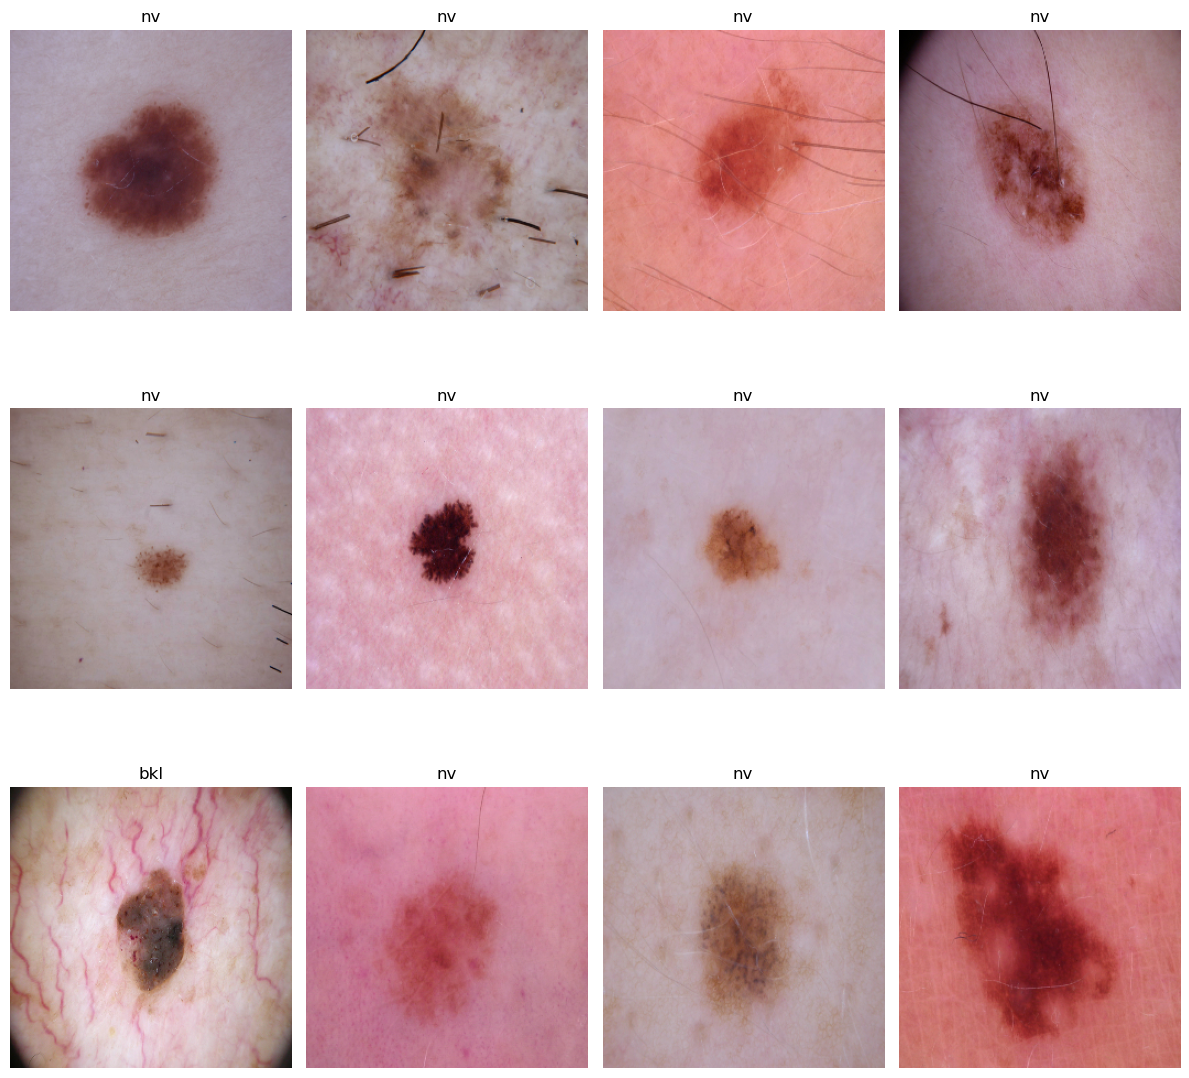

In [15]:
# --- VISUALIZE SAMPLE IMAGES ---
plt.figure(figsize=(12, 12))
for images, labels in train_ds.take(1):
    for i in range(12):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")
plt.tight_layout()
plt.show()


In [16]:
# --- DATA AUGMENTATION ---
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2)
])

In [28]:
# classes
n_classes = 7

In [35]:
# --- MODEL BUILDING --- First bad one!
model = models.Sequential([
    layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS)),
    data_augmentation,

    layers.Conv2D(32, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2), padding="same"),

    layers.Conv2D(32, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2), padding="same"),

    layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2), padding="same"),

    layers.Conv2D(128, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2), padding="same"),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(n_classes, activation="softmax")
])

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_24 (Conv2D)                   │ (None, 256, 256, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_24 (MaxPooling2D)      │ (None, 128, 128, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_25 (Conv2D)                   │ (None, 128, 128, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_25 (MaxPooling2D)      │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_26 (Conv2D)                   │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_26 (MaxPooling2D)      │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_27 (Conv2D)                   │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_27 (MaxPooling2D)      │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_6 (Flatten)                  │ (None, 32768)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 64)                  │       2,097,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 7)                   │             455 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,200,167 (8.39 MB)

 Trainable params: 2,200,167 (8.39 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
# --- COMPILE MODEL ---
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [37]:
# --- CALLBACKS ---
#early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)


In [38]:
#for batch_images, batch_labels in val_ds.take(1):   ---- checking validation dataset
    #print("Validation batch shape:", batch_images.shape)
    #print("Validation batch labels:", batch_labels.numpy()[:10])


In [42]:
# --- TRAIN FIRST(BAD??) MODEL --- 
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    class_weight=class_weights,
    #callbacks=[early_stopping],
    verbose=1
)

Epoch 1/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 229s 913ms/step - accuracy: 0.4023 - loss: 1.5172 - val_accuracy: 0.5854 - val_loss: 1.1584
Epoch 2/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 218s 870ms/step - accuracy: 0.3180 - loss: 1.5521 - val_accuracy: 0.4016 - val_loss: 1.6049
Epoch 3/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 252s 1s/step - accuracy: 0.3774 - loss: 1.5246 - val_accuracy: 0.1069 - val_loss: 1.9698
Epoch 4/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 246s 981ms/step - accuracy: 0.3967 - loss: 1.4736 - val_accuracy: 0.3407 - val_loss: 1.4646
Epoch 5/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 250s 996ms/step - accuracy: 0.4506 - loss: 1.4315 - val_accuracy: 0.5465 - val_loss: 1.2286
Epoch 6/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 225s 896ms/step - accuracy: 0.4597 - loss: 1.4021 - val_accuracy: 0.5485 - val_loss: 1.2375
Epoch 7/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 237s 946ms/step - accuracy: 0.4759 - loss: 1.3960 - val_accuracy: 0.5395 - val_loss: 1.1388
Epoch 8/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 220s 875ms/step - accuracy: 0.4870 - lo

In [43]:
def plot_history(history):
    fig, ax = plt.subplots(1, 2, figsize=(15,5))
    ax[0].set_title('loss')
    ax[0].plot(history.epoch, history.history["loss"], label="Train loss")
    ax[0].plot(history.epoch, history.history["val_loss"], label="Validation loss")
    ax[1].set_title('accuracy')
    ax[1].plot(history.epoch, history.history["accuracy"], label="Train acc")
    ax[1].plot(history.epoch, history.history["val_accuracy"], label="Validation acc")
    ax[0].legend()
    ax[1].legend()

In [44]:
def plot_compare_history(history, name_history, history_1, name_history_1):

    fig, ax = plt.subplots(1, 2, figsize=(15,5))

    ax[0].set_title('loss')

    ax[0].plot(history.epoch, history.history["loss"], label="Train loss " + name_history)
    ax[0].plot(history.epoch, history.history["val_loss"], label="Validation loss " + name_history)

    ax[0].plot(history_1.epoch, history_1.history["loss"], label="Train loss " + name_history_1)
    ax[0].plot(history_1.epoch, history_1.history["val_loss"], label="Validation loss " + name_history_1)

    ax[1].set_title('Accuracy')

    ax[1].plot(history.epoch, history.history["accuracy"], label="Train Accuracy " + name_history)
    ax[1].plot(history.epoch, history.history["val_accuracy"], label="Validation Accuracy " + name_history)

    ax[1].plot(history_1.epoch, history_1.history["accuracy"], label="Train Accuracy " + name_history_1)
    ax[1].plot(history_1.epoch, history_1.history["val_accuracy"], label="Validation Accuracy " + name_history_1)

    ax[0].legend()
    ax[1].legend()

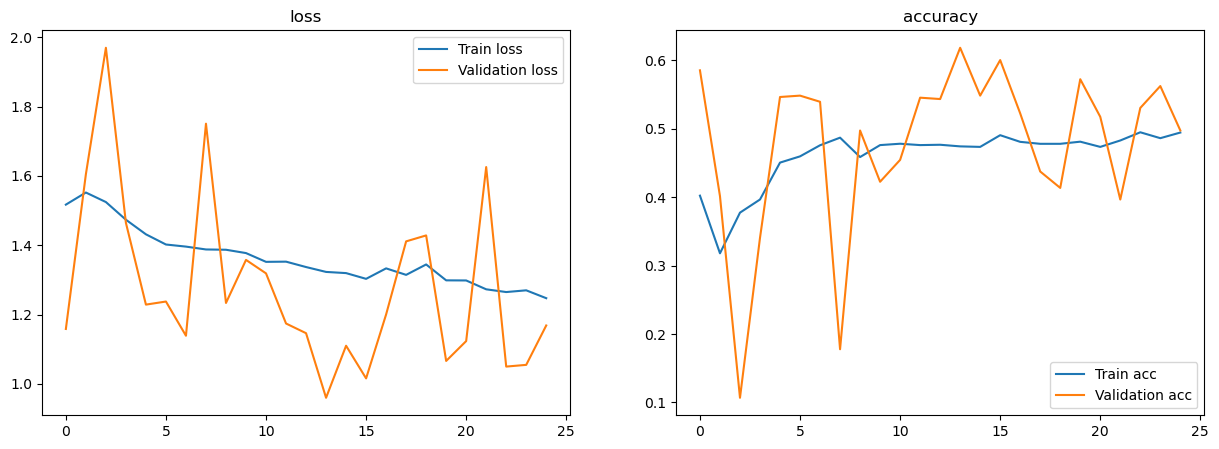

In [45]:
plot_history(history)

In [46]:
scores = model.evaluate(test_ds)

32/32 ━━━━━━━━━━━━━━━━━━━━ 32s 243ms/step - accuracy: 0.4591 - loss: 1.2653
